# FYP Cybersecurity Browser Extension
Authoir :Yap Zheng Xian
Student ID:B2300174

## Import essential Data Handeling Package

In [2]:
#Import essential package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Import and Load the Dataframe

In [3]:
#Set working directory
#os.chdir("C:/Users/Yap Zheng Xian/Programming/Extension/cyber-extension/python-backend/")
#Check working directory
#os.getcwd()
#Import dataset
#data = pd.read_csv("Cleaned Dataset.csv",encoding='latin-1')
#data=pd.read_csv('C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/Dataset/Cleaned Dataset.csv')
data=pd.read_csv('C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/Cleaned Dataset.csv')


# Verify Dataset

In [3]:
# Check how many URLs start with http or https
has_http = data['input'].str.startswith('http').sum()
total = len(data)

print(f"URLs with prefix: {has_http} out of {total}")

if has_http < total and has_http > 0:
    print("⚠️ Warning: Your dataset is inconsistent! Some URLs have prefixes and some don't.")
    # Quick fix: Add 'https://' to those missing a prefix
    #data['input']=data['input'].apply(lambda x: x if x.startswith('http') else 'https://' + x)
elif has_http == 0:
    print("✅ Consistent: No URLs have prefixes.")
else:
    print("✅ Consistent: All URLs have prefixes.")


URLs with prefix: 12037378 out of 12037378
✅ Consistent: All URLs have prefixes.


In [ ]:
#data.to_csv('Cleaned Dataset.csv',index=False)
data.tail(50)

In [4]:
#data.count()
#data.drop_duplicates()
data.count()

input    12037378
label    12037378
dtype: int64

In [4]:
data['label'].value_counts()

label
phishing      6126187
legitimate    5911191
Name: count, dtype: int64

In [4]:
#Shuffle and Truncate the dataset
data=data.sample(frac=1).reset_index(drop=True).head(500000)
print(data.count())

input    500000
label    500000
dtype: int64


## Check the Max Lenght in URLs

In [ ]:
data['len'] = data['input'].apply(len)

print(f"Average URL length: {data['input'].mean():.2f}")
print(f"95th percentile length: {data['input'].quantile(0.95):.2f}")
print(f"Maximum URL length: {data['input'].max()}")

# Manual downsampling with Balanced Class


In [5]:
import pandas as pd
from sklearn.utils import resample

# Assuming 'df' is your DataFrame and 'label' is the column name
# Get the unique class labels
labels = data['label'].unique()
target_size = 5900000 # Set your desired, balanced size

list_of_dfs = []
for specific_label in labels:
    # Separate the class
    data_class = data[data['label'] == specific_label]
    
    # Downsample with replacement=False if the class size is larger than the target size
    if len(data_class) >= target_size:
        data_class_downsampled = resample(data_class, 
                                        replace=False,     # Sample without replacement
                                        n_samples=target_size, # To specified size
                                        random_state=42)   # Reproducible results
        list_of_dfs.append(data_class_downsampled)
    else:
        # Optionally handle classes smaller than target_size (e.g., keep them as is or upsample)
        list_of_dfs.append(data_class)

# Combine all the balanced class DataFrames
balanced_data= pd.concat(list_of_dfs)

# Shuffle the combined data
data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new class distribution
print(balanced_data['label'].value_counts())


label
phishing      5900000
legitimate    5900000
Name: count, dtype: int64


In [6]:
data['label'].value_counts()

label
legitimate    5900000
phishing      5900000
Name: count, dtype: int64

##

## Import the Tokenizer for URL Preprocessing

## Option 1: DistillledBERT Tokenizer

In [13]:
#tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
from transformers import  DistilBertTokenizer, MobileBertTokenizer, MobileBertForSequenceClassification

# 1. Define the model name
MODEL_NAME = 'distilbert-base-uncased'

# 2. Load the smaller DistilBERT Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

## Option 2: MiniLM (Not In Use)

### Import All-MiniLM-V6 Sentence Transformer

In [ ]:
from sentence_transformers import SentenceTransformer

# 1. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

data['token'] = [None] * len(data) # Initialize the 'token' column

for i in range(0,len(data)):
  #output=tokenizer(data['input'][i], truncation=True, padding='max_length')
  token= model.encode(data['label'][i])
  data['token'][i]=token

#data.head(5)


c:\Users\Yap Zheng Xian\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,input,label,token
0,indigobaby.ru,legitimate,"[-0.12744796, 0.041306034, 0.0011082705, -0.04..."
1,oymrrgx.net,phishing,"[-0.06483098, -0.01517658, -8.4113926e-05, -0...."
2,stanbicibtc.com,legitimate,"[-0.12744796, 0.041306034, 0.0011082705, -0.04..."
3,hjbjizvy0mk66sdo.biz,phishing,"[-0.06483098, -0.01517658, -8.4113926e-05, -0...."
4,gsrealty.co.in,phishing,"[-0.06483098, -0.01517658, -8.4113926e-05, -0...."


### Save MiniLM Tokenised Dataset 

In [9]:
import pandas as pd
data.to_csv('Cleaned Dataset With MiniLM.csv',index=False)

# Manually Check Dataset 

In [9]:
train_df.head(5)

,input,label
3531891,https://vmykllyidqjdfbqyd.cc,phishing
6832424,https://styynaudcgdl.com,phishing
10012050,https://courtweek.com/,legitimate
9898998,https://ycsqidablyhoosieraw.com,phishing
8209151,http://www.ngofontana.org/,legitimate


In [11]:
val_df.head(5)

,input,label
176792,https://secureyourhometoday.com,legitimate
121175,https://irdhqfpnzdqvupfqm.net,phishing
478799,https://amapoliajoyeria.com,phishing
85416,https://peerhive.com,phishing
54224,https://playslotscasinos.com,legitimate


In [21]:
test_df.head(5)

,input,label
65566,https://instagram-copyrightk.tk/,phishing
303959,https://comunicacao-alb.com.br,phishing
349833,https://tk-ugrasport.ru,legitimate
1721,https://fairytalechristmas.blogspot.com,legitimate
63623,https://trafficscotland.mobi,legitimate


# Split Dataset

In [6]:
from sklearn.model_selection import train_test_split

# Select relevant columns (URL and label) for model training
df = data[['input', 'label']]
#df = data[['input', 'label','token']]

# Split the dataset into training (70%) and test (30%) sets
# Stratify ensures an even distribution of labels across splits
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

# Split the test set further into validation (50%) and test (50%) sets
test_df, val_df = train_test_split(
    test_df,
    test_size=0.5,
    random_state=42,
    stratify=test_df['label']
)
# CRITICAL: Reset indices for Hugging Face compatibility
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Display the size of each split
print(f"Training set: {len(train_df)}, Validation set: {len(val_df)}, Test set: {len(test_df)}")

Training set: 8260000, Validation set: 1770000, Test set: 1770000


# Old Version Tokenize Technique

## Encode the Dataset With Tokenizer

In [ ]:
# Tokenize the 'input' column (urls) for training, validation, and test sets
train_encodings = tokenizer(
    list(train_df['input'].values),
    truncation=True,
    padding=True,
    max_length=64,
)

val_encodings = tokenizer(
    list(val_df['input'].values),
    truncation=True,
    padding=True,
    max_length=64,
)

test_encodings = tokenizer(
    list(test_df['input'].values),
    truncation=True,
    padding=True,
    max_length=64,
)

# New Tokenzier Technique (New Version)

## Import Distileed BERT Tokenizer

In [6]:
from datasets import Dataset, DatasetDict
from transformers import DistilBertTokenizer

# 1. Convert your Pandas DataFrames to Hugging Face Datasets
raw_ds = DatasetDict({
    'train': Dataset.from_pandas(train_df[['input', 'label']]),
    'val': Dataset.from_pandas(val_df[['input', 'label']]),
    'test': Dataset.from_pandas(test_df[['input', 'label']])
})

# 2. Define an optimized map function
def preprocess_function(examples):
    # This line ensures every worker process has access to the tokenizer
    from transformers import DistilBertTokenizer
    worker_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    
    # Map 'phishing' to 1 and 'legitimate' to 0
    label_map = {'phishing': 1, 'legitimate': 0}
    labels = [label_map[l] for l in examples['label']]
    
    # Tokenize
    tokenized = worker_tokenizer(examples['input'], truncation=True, padding='max_length', max_length=64)
    tokenized['labels'] = labels
    return tokenized
  
# 3. Tokenize in parallel (This uses all your CPU cores!)
tokenized_ds = raw_ds.map(preprocess_function, batched=True, num_proc=6)

# 4. Save to disk (This creates the 'processed_data' folder)
tokenized_ds.save_to_disk("processed_url_data")

Saving the dataset (2/2 shards): 100%|██████████| 1770000/1770000 [01:26<00:00, 20406.58 examples/s] 


### Clean Storage

In [7]:
import gc
del train_df, val_df, test_df, raw_ds, tokenized_ds
gc.collect()

1030

### Load Dataset

In [2]:
from datasets import load_from_disk

# Loads 1 million+ rows in seconds
loaded_ds = load_from_disk("processed_url_data")

# These are now ready for the Trainer
train_dataset = loaded_ds['train']
val_dataset = loaded_ds['val']
test_dataset = loaded_ds['test']

c:\Users\Yap Zheng Xian\Documents\Programming\Extension\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train DistilledBERT Model

In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding,EarlyStoppingCallback,DistilBertForSequenceClassification
from datasets import load_from_disk
from sklearn.metrics import precision_recall_fscore_support

model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# 1. Load the pre-processed data from the 'processed_url_data' folder
loaded_ds = load_from_disk("processed_url_data")

columns_to_remove = ['input', 'label'] 

# 3. Remove them from the training/val/test sets
train_dataset = loaded_ds['train'].remove_columns(columns_to_remove)
val_dataset = loaded_ds['val'].remove_columns(columns_to_remove)

# 2. Use a Data Collator
# This handles dynamic padding efficiently during training
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Define TrainingArguments (using the optimizations we discussed)
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32, # Balanced for 1M rows
    per_device_eval_batch_size=32,
    num_train_epochs=1,# With 1M rows, 1 epoch is likely enough
    
    # --- LOGGING OPTIMIZATION ---
    logging_strategy="steps",     # ⚡ Change from "epoch" to "steps"
    logging_steps=100,            # ⚡ Log metrics every 100 training steps
    
    weight_decay=0.01,
    learning_rate=2e-5,
    fp16=True,                      # Essential for speed/VRAM
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    report_to="none"
)
# 4.define compute Metric
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }
    
# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, # Pass the loaded dataset directly
    eval_dataset=val_dataset,
    data_collator=data_collator,      # Speeds up processing
    compute_metrics=compute_metrics,
    load_best_model_at_end=True,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 5. Launch Training
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.261300,0.260792,0.960531,0.812514,0.880344


TrainOutput(global_step=258125, training_loss=0.27723613873497915, metrics={'train_runtime': 29710.0544, 'train_samples_per_second': 278.02, 'train_steps_per_second': 8.688, 'total_flos': 1.3677258911232e+17, 'train_loss': 0.27723613873497915, 'epoch': 1.0})

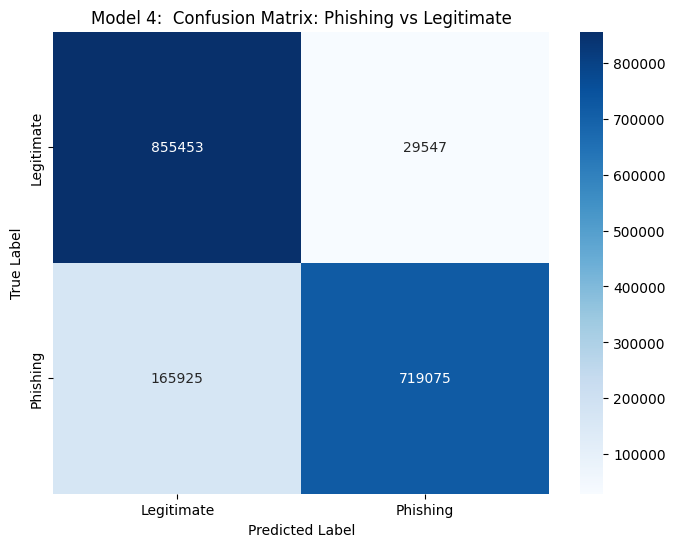

False Positive Rate (Blocked Good Sites): 3.34%


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report

# 1. Get predictions from the trainer
output = trainer.predict(val_dataset)
y_true = output.label_ids
y_pred = np.argmax(output.predictions, axis=-1)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Model 5:  Confusion Matrix: Phishing vs Legitimate')
plt.savefig('Model 5 confusion Matrix.png')
plt.show()

# Calculate specific "Safety" metrics
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
print(f"False Positive Rate (Blocked Good Sites): {false_positive_rate:.2%}")

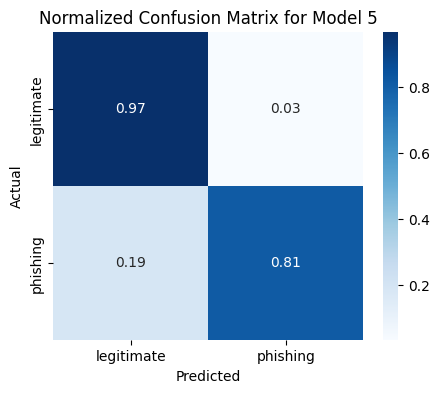

              precision    recall  f1-score   support

  legitimate       0.84      0.97      0.90    885000
    phishing       0.96      0.81      0.88    885000

    accuracy                           0.89   1770000
   macro avg       0.90      0.89      0.89   1770000
weighted avg       0.90      0.89      0.89   1770000



In [28]:
from sklearn.metrics import classification_report
# Normalized matrix (percentages by true class)
class_names = ['legitimate', 'phishing']  # adjust order/names to match your mapping
cm = confusion_matrix(y_true, y_pred)

cmn = cm.astype('float') / cm.sum(axis=1)[:, None]
plt.figure(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); 
plt.ylabel('Actual'); 
plt.title('Normalized Confusion Matrix for Model 5')
plt.savefig('Model 5 Normalised Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

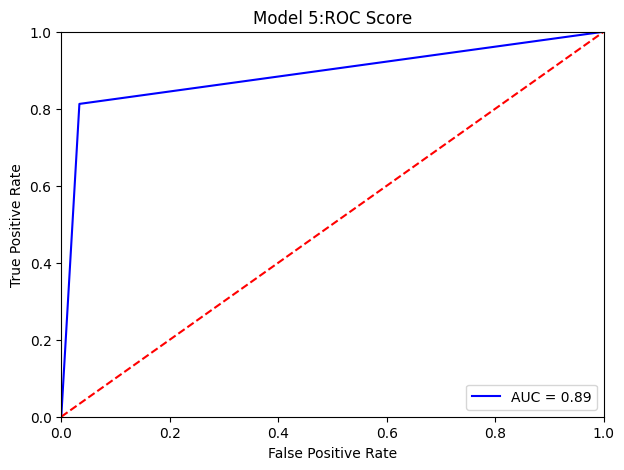

In [20]:
#Plot  AUC-ROC CURVE
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

plt.figure(figsize=(7, 5))

fpr, tpr, threshold = metrics.roc_curve(y_true,y_pred)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Model 5:ROC Score')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig('Model 5 ROC Score.png')
plt.show()

In [17]:
# Evaluate the model on the test dataset
columns_to_remove = ['input', 'label'] 
test_dataset = loaded_ds['test'].remove_columns(columns_to_remove)
test_results = trainer.evaluate(test_dataset)

# Display the evaluation results
print(test_results)

{'eval_loss': 0.26014283299446106, 'eval_precision': 0.9609165500368586, 'eval_recall': 0.8130418079096046, 'eval_f1': 0.8808158608600276, 'eval_runtime': 1587.6188, 'eval_samples_per_second': 1114.877, 'eval_steps_per_second': 34.84, 'epoch': 1.0}


In [18]:
for key, value in test_results.items():
    print(f"{key}: {value}")

eval_loss: 0.26014283299446106
eval_precision: 0.9609165500368586
eval_recall: 0.8130418079096046
eval_f1: 0.8808158608600276
eval_runtime: 1587.6188
eval_samples_per_second: 1114.877
eval_steps_per_second: 34.84
epoch: 1.0


In [21]:
#Plot R^2 Curve
from sklearn.metrics import r2_score,f1_score
print ("R^2 Value", r2_score(y_true, y_pred))
print ("F1 Score", f1_score(y_true, y_pred))

R^2 Value 0.5582553672316384
F1 Score 0.8803444125997324


In [15]:
import torch
# Specify the directory where the model and tokenizer will be saved
save_directory = "./model"
os.makedirs(save_directory, exist_ok=True) 


# Save the trained model and tokenizer to the specified directory
trainer.save_model(save_directory)              # Save model via Trainer
tokenizer.save_pretrained(save_directory)        # Save tokenizer to the same directory

# Save the model and tokenizer again in case you want to save them separately
model.save_pretrained(save_directory)            # Save model directly
tokenizer.save_pretrained(save_directory)        # Save tokenizer directly

# Save the model and tokenizer to the output directory defined in TrainingArguments
model.save_pretrained(training_args.output_dir)  # Save model to output directory
tokenizer.save_pretrained(training_args.output_dir)  # Save tokenizer to output directory

# Save the model's state_dict (weights) separately in case you need it for later use
torch.save(model.state_dict(), './results/pytorch_model.bin')  # Save model weights

print(f"Model and tokenizer successfully saved to: {save_directory}")


Model and tokenizer successfully saved to: ./model


In [ ]:
import torch
import torch.nn.functional as F

def predict_url(url, model, tokenizer):
    # 1. Normalize (Must match your training preprocessing!)
    normalized_url = url if url.startswith('http') else 'https://' + url
    
    # 2. Tokenize
    inputs = tokenizer(
        normalized_url, 
        return_tensors="pt", 
        truncation=True, 
        padding='max_length', 
        max_length=64
    )
    
    # 3. Move inputs to the same device as the model (GPU or CPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # 4. Predict
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        # Convert logits to probabilities (0.0 to 1.0)
        probs = F.softmax(logits, dim=-1)
        
    # 5. Interpret Results
    prediction_idx = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][prediction_idx].item()
    
    label_map = {0: "✅ Legitimate", 1: "🚨 Phishing"}
    result = label_map[prediction_idx]
    
    return f"URL: {url}\nResult: {result} ({confidence:.2%} confidence)"

# --- Test it out ---
test_link = "www.secure-login-bank-verification.com/update"
print(predict_url(test_link, model, tokenizer))

## Import MobileBERT Tokenizer

In [1]:
#tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
from transformers import MobileBertTokenizer, MobileBertForSequenceClassification

# 1. Define the model name
MOBILEBERT_MODEL_NAME = 'google/mobilebert-uncased'

# 2. Load the MobileBERT Tokenizer
mobilebert_tokenizer = MobileBertTokenizer.from_pretrained(MOBILEBERT_MODEL_NAME)

# 3. Load the MobileBERT Model
mobilebert_model = MobileBertForSequenceClassification.from_pretrained(MOBILEBERT_MODEL_NAME, num_labels=2)

c:\Users\Yap Zheng Xian\Documents\Programming\Extension\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
from datasets import Dataset, DatasetDict


# 1. Convert your Pandas DataFrames to Hugging Face Datasets
raw_ds = DatasetDict({
    'train': Dataset.from_pandas(train_df[['input', 'label']]),
    'val': Dataset.from_pandas(val_df[['input', 'label']]),
    'test': Dataset.from_pandas(test_df[['input', 'label']])
})

# 2. Define an optimized map function
def preprocess_function(examples):
    # This line ensures every worker process has access to the tokenizer
    from transformers import MobileBertTokenizer
    worker_tokenizer = MobileBertTokenizer.from_pretrained('google/mobilebert-uncased')
    
    # Map 'phishing' to 1 and 'legitimate' to 0
    label_map = {'phishing': 1, 'legitimate': 0}
    labels = [label_map[l] for l in examples['label']]
    
    # Tokenize
    tokenized = worker_tokenizer(examples['input'], truncation=True, padding='max_length', max_length=64)
    tokenized['labels'] = labels
    return tokenized
  
# 3. Tokenize in parallel (This uses all your CPU cores!)
tokenized_ds = raw_ds.map(preprocess_function, batched=True, num_proc=6)

# 4. Save to disk (This creates the 'processed_data' folder)
tokenized_ds.save_to_disk("processed_url_data-MobileBERT")

NameError: name 'train_df' is not defined

In [9]:
import gc
del train_df, val_df, test_df, raw_ds, tokenized_ds
gc.collect()

NameError: name 'tokenized_ds' is not defined

In [ ]:
from datasets import load_from_disk

# Loads 1 million+ rows in seconds
loaded_ds = load_from_disk("processed_url_data-MobileBERT")

# These are now ready for the Trainer
train_dataset = loaded_ds['train']
val_dataset = loaded_ds['val']
test_dataset = loaded_ds['test']

In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding,EarlyStoppingCallback,MobileBertForSequenceClassification
from datasets import load_from_disk
from sklearn.metrics import precision_recall_fscore_support

model = MobileBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# 1. Load the pre-processed data from the 'processed_url_data' folder
loaded_ds = load_from_disk("processed_url_data-MobileBERT")

columns_to_remove = ['input', 'label'] 

# 3. Remove them from the training/val/test sets
train_dataset = loaded_ds['train'].remove_columns(columns_to_remove)
val_dataset = loaded_ds['val'].remove_columns(columns_to_remove)

# 2. Use a Data Collator
# This handles dynamic padding efficiently during training
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Define TrainingArguments (using the optimizations we discussed)
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32, # Balanced for 1M rows
    per_device_eval_batch_size=32,
    num_train_epochs=1,# With 1M rows, 1 epoch is likely enough
    
    # --- LOGGING OPTIMIZATION ---
    logging_strategy="steps",     # ⚡ Change from "epoch" to "steps"
    logging_steps=100,            # ⚡ Log metrics every 100 training steps
    
    weight_decay=0.01,
    learning_rate=2e-5,
    fp16=True,                      # Essential for speed/VRAM
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    report_to="none"
)
# 4.define compute Metric
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }
    
# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, # Pass the loaded dataset directly
    eval_dataset=val_dataset,
    data_collator=data_collator,      # Speeds up processing
    compute_metrics=compute_metrics,
    load_best_model_at_end=True,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 5. Launch Training
trainer.train()

# Training the Model (Old Version)

## Model 1: Distiled BERT

In [12]:
from sklearn.metrics import precision_recall_fscore_support
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer, Trainer, TrainingArguments
import os
import torch 

# 1. Define the model name
MODEL_NAME = 'distilbert-base-uncased'

# 2. Load the smaller DistilBERT Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# 3. Load the smaller DistilBERT Model (6 layers, 66M parameters)
#    We assume 'num_labels=2' for binary classification (legitimate vs. phishing)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
# 1. DEFINE YOUR CUSTOM DATASET CLASS
class TextDataset(torch.utils.data.Dataset):
    # It's fine to pass 'status' here, but the key returned below must be 'labels'.
    def __init__(self, encodings, status):
        self.encodings = encodings
        self.status = status 

    # Return a single item at the specified index
    def __getitem__(self, idx):
        # Convert encoding values to tensors (input_ids, attention_mask, etc.)
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        
        # ❗ CRITICAL FIX: Change key from 'status' to 'labels'
        item['labels'] = torch.tensor(self.status[idx], dtype=torch.long) 
        
        return item

    # Return the total number of samples in the dataset
    def __len__(self):
        return len(self.status)

# Map labels to integer values (if not already integers)
# Assuming 'phishing' maps to 1 and 'legitimate' maps to 0

train_labels = train_df['label'].map({'phishing': 1, 'legitimate': 0}).tolist()
val_labels = val_df['label'].map({'phishing': 1, 'legitimate': 0}).tolist()
test_labels = test_df['label'].map({'phishing': 1, 'legitimate': 0}).tolist()


# Create dataset objects for training, validation, and test sets
train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)
test_dataset = TextDataset(test_encodings, test_labels)

## Run here if using MiniLM Embedding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data=pd.read_csv('C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/Cleaned Dataset With MiniLM.csv')


In [ ]:
import torch
import pandas as pd
from transformers import Trainer, TrainingArguments


# 1. DEFINE YOUR CUSTOM DATASET CLASS FOR EMBEDDINGS
class CustomEmbeddingDataset(torch.utils.data.Dataset):
    """
    A PyTorch Dataset class to work with pre-computed embeddings.
    It assumes the DataFrame has a 'token' column with embeddings (e.g., list of floats)
    and a 'label' column with integer labels.
    """
    def __init__(self, dataframe):
        # Reset index to ensure 0-based sequential indexing.
        # This is crucial to prevent the kind of KeyError you saw before.
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        This method is called by the DataLoader to get a single data sample.
        """
        # Get the pre-computed embedding and label for the given index.
        # We assume the 'token' column contains a list or array of floats.
        embedding = self.df.loc[idx, 'token']
        label = self.df.loc[idx, 'label']
        
        # The Trainer expects a dictionary. The keys must match the arguments
        # of your model's forward() method.
        item = {
            # For pre-computed embeddings, the conventional key is 'inputs_embeds'.
            # Your model must be able to accept this as an argument.
            'inputs_embeds': torch.tensor(embedding, dtype=torch.float),
            
            # The Trainer specifically looks for the 'labels' key to compute loss.
            'labels': torch.tensor(label, dtype=torch.long)
        }
        return item

# 2. CREATE THE DATASET OBJECTS
# The DataFrames are passed directly to our new dataset class.
train_dataset = CustomEmbeddingDataset(train_df)
val_dataset = CustomEmbeddingDataset(val_df)
test_dataset = CustomEmbeddingDataset(test_df) # if you have one

# Now you can pass `train_dataset` and `val_dataset` to the Hugging Face Trainer.
# The rest of your Trainer setup code will work as long as the model is configured correctly.

# Example of using it with your existing Trainer setup:
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics
# )
#

c:\Users\Yap Zheng Xian\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Iterative Training Model (Old Version)

## For Distilled BERT Tokenizer

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.322200,0.366815,0.925969,0.753250,0.830727
2,0.316300,0.388142,0.900224,0.781444,0.836639
3,0.314900,0.370273,0.909323,0.771333,0.834663
4,0.305600,0.384562,0.896274,0.787028,0.838106
5,0.290700,0.383353,0.864317,0.811306,0.836973
6,0.276500,0.394069,0.889163,0.789528,0.836389
7,0.263600,0.429374,0.869157,0.796944,0.831486


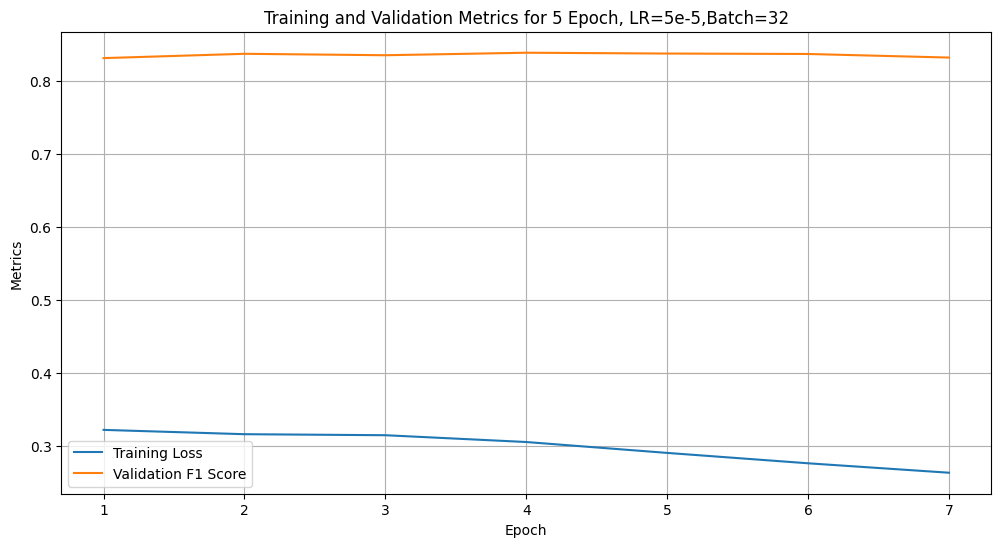

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import os
from transformers import TrainingArguments, Trainer
import matplotlib.pyplot as plt
import pandas as pd
from transformers import EarlyStoppingCallback

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# --- FIX FOR KeyError ---
# Reset the index of your DataFrames to prevent the KeyError.
# This ensures a 0-based sequential index, which the Trainer expects.
if isinstance(train_df, pd.DataFrame):
    train_df = train_df.reset_index(drop=True)
if isinstance(val_df, pd.DataFrame):
    val_df = val_df.reset_index(drop=True)


training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=25,
    weight_decay=0.01,
    learning_rate=1e-5,
    report_to="none",
    fp16=True,
    #hidden_dropout_prob=0.2,
    logging_strategy="epoch",
    logging_steps=50, # Note: This is ignored when logging_strategy="epoch"
    save_total_limit=1,
    save_steps=1000, # Note: This may not have an effect with save_strategy="epoch"
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]#stop train if the accuracy did not changefroo3 times
)

os.environ["WANDB_MODE"] = "disabled"

# Store training history
history = trainer.train()

# --- SUGGESTION: More robust plotting logic ---

# Access the complete log history from the trainer's state
log_history = trainer.state.log_history

# Extract training loss, validation F1, and validation accuracy points, associating them with their epoch
train_points = [(log['epoch'], log['loss']) for log in log_history if 'loss' in log and 'epoch' in log]
eval_f1_points = [(log['epoch'], log['eval_f1']) for log in log_history if 'eval_f1' in log and 'epoch' in log]
eval_accuracy_points = [(log['epoch'], log['eval_accuracy']) for log in log_history if 'eval_accuracy' in log and 'epoch' in log]

# Unzip into separate lists for plotting, ensuring they are sorted by epoch
if train_points:
    train_epochs, train_loss = zip(*sorted(train_points))
else:
    train_epochs, train_loss = [], []

if eval_f1_points:
    eval_f1_epochs, eval_f1 = zip(*sorted(eval_f1_points))
else:
    eval_f1_epochs, eval_f1 = [], []

if eval_accuracy_points:
    eval_accuracy_epochs, eval_accuracy = zip(*sorted(eval_accuracy_points))
else:
    eval_accuracy_epochs, eval_accuracy = [], []

# Plotting the learning curve
plt.figure(figsize=(12, 6))

if train_epochs:
    plt.plot(train_epochs, train_loss, label='Training Loss')
if eval_f1_epochs:
    plt.plot(eval_f1_epochs, eval_f1, label='Validation F1 Score')
if eval_accuracy_epochs:
    plt.plot(eval_accuracy_epochs, eval_accuracy, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.title('Training and Validation Metrics for 5 Epoch, LR=5e-5,Batch=32')
plt.legend()
plt.grid(True)
plt.savefig('Learning Curve Metrics for Model 4.png')
plt.show()


## Plot Confusion Matrix

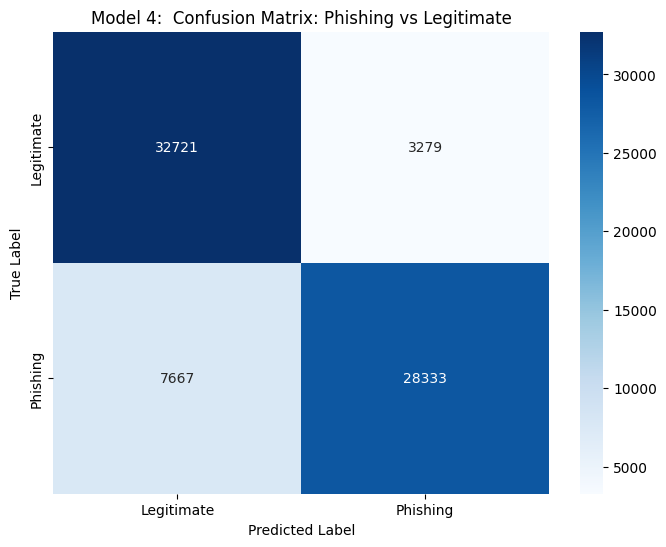

False Positive Rate (Blocked Good Sites): 9.11%


In [43]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions from the trainer
output = trainer.predict(val_dataset)
y_true = output.label_ids
y_pred = np.argmax(output.predictions, axis=-1)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Model 4:  Confusion Matrix: Phishing vs Legitimate')
plt.savefig('Model 4 confusion Matrix.png')
plt.show()

# Calculate specific "Safety" metrics
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
print(f"False Positive Rate (Blocked Good Sites): {false_positive_rate:.2%}")

## Evaluate the Model


In [44]:
# Evaluate the model on the test dataset
test_results = trainer.evaluate(test_dataset)

# Display the evaluation results
print(test_results)


{'eval_loss': 0.3878944218158722, 'eval_precision': 0.8951113369969188, 'eval_recall': 0.78275, 'eval_f1': 0.8351684177768557, 'eval_runtime': 52.3563, 'eval_samples_per_second': 1375.193, 'eval_steps_per_second': 42.975, 'epoch': 7.0}


In [45]:
for key, value in test_results.items():
    print(f"{key}: {value}")

eval_loss: 0.3878944218158722
eval_precision: 0.8951113369969188
eval_recall: 0.78275
eval_f1: 0.8351684177768557
eval_runtime: 52.3563
eval_samples_per_second: 1375.193
eval_steps_per_second: 42.975
epoch: 7.0


# Save the Model



In [46]:
# Specify the directory where the model and tokenizer will be saved
save_directory = "./model"
os.makedirs(save_directory, exist_ok=True) 


# Save the trained model and tokenizer to the specified directory
trainer.save_model(save_directory)              # Save model via Trainer
tokenizer.save_pretrained(save_directory)        # Save tokenizer to the same directory

# Save the model and tokenizer again in case you want to save them separately
model.save_pretrained(save_directory)            # Save model directly
tokenizer.save_pretrained(save_directory)        # Save tokenizer directly

# Save the model and tokenizer to the output directory defined in TrainingArguments
model.save_pretrained(training_args.output_dir)  # Save model to output directory
tokenizer.save_pretrained(training_args.output_dir)  # Save tokenizer to output directory

# Save the model's state_dict (weights) separately in case you need it for later use
torch.save(model.state_dict(), './results/pytorch_model.bin')  # Save model weights

print(f"Model and tokenizer successfully saved to: {save_directory}")


Model and tokenizer successfully saved to: ./model


# Load the Tokenizer (DistilledBERT,)

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Define the directory where you saved your files
save_directory = "C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/model"

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(save_directory)

# Load the fine-tuned model
model = DistilBertForSequenceClassification.from_pretrained(save_directory)

# Set the model to evaluation mode (essential for prediction)
model.eval()

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

c:\Users\Yap Zheng Xian\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# Load Model

## Load in the VSC 

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer,Trainer, TrainingArguments
from sklearn.metrics import precision_recall_fscore_support

# Use the same path used for saving!
#LOAD_DIRECTORY = "C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/model"
LOAD_DIRECTORY = "./model"

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(LOAD_DIRECTORY)

# Load the fine-tuned model
model = DistilBertForSequenceClassification.from_pretrained(LOAD_DIRECTORY)

# Set the model to evaluation mode
model.eval()

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Load for the Web Deployment

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Load from the folder you saved earlier
path = "./model"
my_detector = AutoModelForSequenceClassification.from_pretrained(path)
my_tokenizer = AutoTokenizer.from_pretrained(path)

c:\Users\Yap Zheng Xian\Documents\Programming\Extension\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Inference and Predict

## Single URL Predict

In [ ]:
import torch
import torch.nn.functional as F

def predict_url(url, model, tokenizer):
    # 1. Normalize (Must match your training preprocessing!)
    normalized_url = url if url.startswith('http') else 'https://' + url
    
    # 2. Tokenize
    inputs = tokenizer(
        normalized_url, 
        return_tensors="pt", 
        truncation=True, 
        padding='max_length', 
        max_length=64
    )
    
    # 3. Move inputs to the same device as the model (GPU or CPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # 4. Predict
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        # Convert logits to probabilities (0.0 to 1.0)
        probs = F.softmax(logits, dim=-1)
        
    # 5. Interpret Results
    prediction_idx = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][prediction_idx].item()
    
    label_map = {0: "✅ Legitimate", 1: "🚨 Phishing"}
    result = label_map[prediction_idx]
    
    return f"URL: {url}\nResult: {result} ({confidence:.2%} confidence)"

# --- Test it out ---
test_link = "www.Yah0O.com"
print(predict_url(test_link, model, tokenizer))

URL: www.Yah0o.com
Result: 🚨 Phishing (89.66% confidence)


In [ ]:
# --- Continue with your inference steps ---

# 1. Prepare the New URL
#new_url = "<a href=https://rapiescapes.com/benfiprom-fi-cr/>Phishing Website 3</a>" 
new_url = "ljdbdbkcxcn.com" 

encoding = tokenizer.encode_plus(
    new_url,
    max_length=128,          # Match your training max_length
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'      
)

# 2. Make the Prediction
input_ids = encoding['input_ids'].to(device)
attention_mask = encoding['attention_mask'].to(device)

with torch.no_grad():
    output = model(input_ids, attention_mask=attention_mask)
    logits = output.logits
    
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_id = torch.argmax(probabilities).item()
    confidence = probabilities[0, predicted_class_id].item() * 100

# 3. Interpret the Result
result = "PHISHING / MALICIOUS" if predicted_class_id == 1 else "LEGITIMATE / SAFE"

print(f"URL: {new_url}")
print(f"Prediction: {result} with {confidence:.2f}% confidence.")


## Batch Predict

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def batch_predict_urls(url_list, model, tokenizer, batch_size=64):
    # 1. Prepare for GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 2. Tokenize the entire list
    # We add 'https://' normalization here too
    normalized_urls = [u if str(u).startswith('http') else 'https://' + str(u) for u in url_list]
    
    encodings = tokenizer(
        normalized_urls, 
        truncation=True, 
        padding=True, 
        max_length=64, 
        return_tensors="pt"
    )

    # 3. Create a simple Dataset and Loader
    dataset = torch.utils.data.TensorDataset(encodings['input_ids'], encodings['attention_mask'])
    loader = DataLoader(dataset, batch_size=batch_size)

    all_predictions = []
    all_confidences = []

    # 4. Run Inference in Batches
    print(f"Scanning {len(url_list)} URLs...")
    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids, attention_mask = [b.to(device) for b in batch]
            
            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            
            confidences, predictions = torch.max(probs, dim=-1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    # 5. Map 0/1 back to labels
    labels = ["Legitimate" if p == 0 else "Phishing" for p in all_predictions]
    
    return pd.DataFrame({
        'url': url_list,
        'prediction': labels,
        'confidence': all_confidences
    })

# --- Example Usage ---
# new_urls = ["paypa1-security.com", "google.com", "login.microsoft-verify.net"]
# results_df = batch_predict_urls(new_urls, model, tokenizer)
# print(results_df)

# Batch Predict Testing (With CSV File)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def batch_predict_urls(url_list, model, tokenizer, batch_size=64):
    # 1. Prepare for GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 2. Tokenize the entire list
    # We add 'https://' normalization here too
    normalized_urls = [u if str(u).startswith('http') else 'https://' + str(u) for u in url_list]
    
    encodings = tokenizer(
        normalized_urls, 
        truncation=True, 
        padding=True, 
        max_length=64, 
        return_tensors="pt"
    )

    # 3. Create a simple Dataset and Loader
    dataset = torch.utils.data.TensorDataset(encodings['input_ids'], encodings['attention_mask'])
    loader = DataLoader(dataset, batch_size=batch_size)

    all_predictions = []
    all_confidences = []

    # 4. Run Inference in Batches
    print(f"Scanning {len(url_list)} URLs...")
    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids, attention_mask = [b.to(device) for b in batch]
            
            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            
            confidences, predictions = torch.max(probs, dim=-1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    # 5. Map 0/1 back to labels
    labels = ["Legitimate" if p == 0 else "Phishing" for p in all_predictions]
    
    return pd.DataFrame({
        'url': url_list,
        'prediction': labels,
        'confidence': all_confidences
    })

# --- Example Usage ---
# new_urls = ["paypa1-security.com", "google.com", "login.microsoft-verify.net"]
# results_df = batch_predict_urls(new_urls, model, tokenizer)
# print(results_df)

In [ ]:
new_data = pd.read_csv("new_sites.csv")
results = batch_predict_urls(new_data['url_address'].tolist(), model, tokenizer)

# Save the findings
results.to_csv("scanning_results.csv", index=False)

## Plot the Confident Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confidence_distribution(results_df):
    plt.figure(figsize=(10, 6))
    
    # Split the data by prediction type
    phish = results_df[results_df['prediction'] == 'Phishing']['confidence']
    legit = results_df[results_df['prediction'] == 'Legitimate']['confidence']
    
    # Plotting
    sns.histplot(phish, bins=20, kde=True, color='red', label='Phishing Confidence', alpha=0.6)
    sns.histplot(legit, bins=20, kde=True, color='blue', label='Legitimate Confidence', alpha=0.4)
    
    plt.axvline(0.5, color='black', linestyle='--', label='Threshold (50%)')
    plt.title('How Confident is the Model?')
    plt.xlabel('Confidence Score (Probability)')
    plt.ylabel('Number of URLs')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- Run the plot ---
# plot_confidence_distribution(results_df)

# Model 2:BERT Model

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Load the pre-trained BERT model for sequence classification
# num_labels=2 indicates binary classification
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import os

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',            # Directory to save model checkpoints and logs
    eval_strategy="epoch",       # Evaluate at the end of each epoch
    per_device_train_batch_size=32,    # Batch size for training
    per_device_eval_batch_size=32,     # Batch size for evaluation
    num_train_epochs=5,                # Number of training epochs
    weight_decay=0.01,                 # Weight decay for regularization
    report_to="none",                  # Disable reporting to external services like W&B
    fp16=True,                         # Use mixed precision for faster training (if supported by the GPU)
    logging_strategy="epoch",          # Log metrics at the end of each epoch
    logging_steps=50,                  # Log every 50 steps (if logging_strategy="steps")
    save_total_limit=1,                # Keep only the last saved model
    save_steps=500                     # Save the model every 500 steps
)

# Define a function to compute evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)  # Get the predicted class with the highest score

    # Calculate precision, recall, and F1 score (for binary classification)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Create a Trainer instance for fine-tuning the model
trainer = Trainer(
    model=bert_model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=train_dataset,        # Training dataset
    eval_dataset=val_dataset,           # Validation dataset
    compute_metrics=compute_metrics     # Function to calculate evaluation metrics
)

# Disable Weights & Biases logging (if not needed)
os.environ["WANDB_MODE"] = "disabled"

# Start training the model
trainer.train()


# Model 3: MobileBERT

In [ ]:
#tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
from transformers import MobileBertTokenizer, MobileBertForSequenceClassification

# 1. Define the model name
MOBILEBERT_MODEL_NAME = 'google/mobilebert-uncased'

# 2. Load the MobileBERT Tokenizer
mobilebert_tokenizer = MobileBertTokenizer.from_pretrained(MOBILEBERT_MODEL_NAME)

# 3. Load the MobileBERT Model
mobilebert_model = MobileBertForSequenceClassification.from_pretrained(MOBILEBERT_MODEL_NAME, num_labels=2)

In [ ]:
# Tokenize the data for MobileBERT
mobilebert_train_encodings = mobilebert_tokenizer(train_texts, truncation=True, padding=True, max_length=512)
mobilebert_val_encodings = mobilebert_tokenizer(val_texts, truncation=True, padding=True, max_length=512)

In [ ]:
# Create PhishingDataset for MobileBERT
mobilebert_train_dataset = PhishingDataset(mobilebert_train_encodings, train_labels)
mobilebert_val_dataset = PhishingDataset(mobilebert_val_encodings, val_labels)

In [ ]:
# Define TrainingArguments for MobileBERT
mobilebert_training_args = TrainingArguments(
    output_dir='./results-mobilebert',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs-mobilebert',
    logging_steps=10,
    evaluation_strategy='epoch'
)

# Initialize the Trainer for MobileBERT
mobilebert_trainer = Trainer(
    model=mobilebert_model,
    args=mobilebert_training_args,
    train_dataset=mobilebert_train_dataset,
    eval_dataset=mobilebert_val_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
# Train the MobileBERT model
mobilebert_trainer.train()

# Evaluate the MobileBERT model
mobilebert_trainer.evaluate()

# Save the MobileBERT model
mobilebert_trainer.save_model('mobilebert_model')

# Model Evaluation (Unused Code)

## Split dataset into test, train, validate

In [2]:
from sklearn.model_selection import train_test_split

data=pd.read_csv('C:/Users/Yap Zheng Xian/Documents/Programming/Extension/notebook/Dataset/Cleaned Dataset.csv')
data=data.sample(frac=1).reset_index(drop=True).head(150000)
# Select relevant columns (URL and label) for model training
df = data[['input', 'label']]

# Drop rows where the 'label' column has missing values
#df = df.dropna(subset=['status'])

# Split the dataset into training (70%) and test (30%) sets
# Stratify ensures an even distribution of labels across splits
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

# Split the 15% of the training set as the validate dataset 
train_df,val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df['label']
)

# Display the size of each split
print(f"Training set: {len(train_df)}, Validation set: {len(val_df)}, Test set: {len(test_df)}")


Training set: 89250, Validation set: 15750, Test set: 45000


## Display the confusion Matrix using the Model loaded

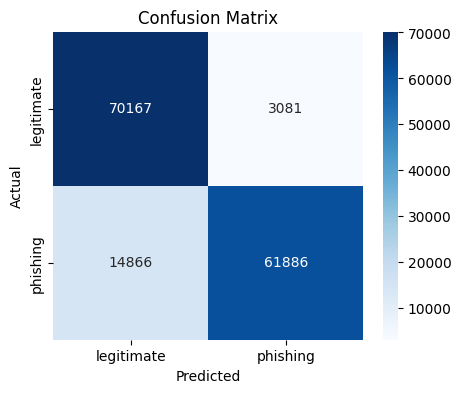

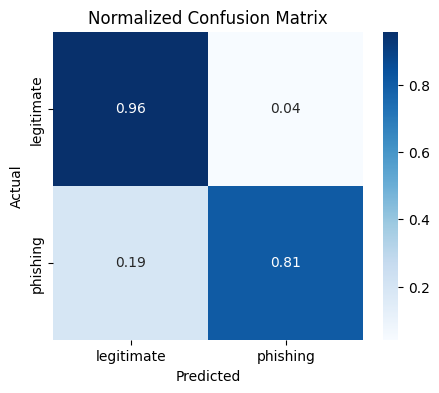

              precision    recall  f1-score   support

  legitimate       0.83      0.96      0.89     73248
    phishing       0.95      0.81      0.87     76752

    accuracy                           0.88    150000
   macro avg       0.89      0.88      0.88    150000
weighted avg       0.89      0.88      0.88    150000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

# If labels are strings, map them to ints (adjust mapping to your labels)
label_map = {'legitimate': 0, 'phishing': 1}
if data['label'].dtype == object:
    y_true = data['label'].map(label_map).values
else:
    y_true = data['label'].values

# Batched prediction to avoid OOM
batch_size = 64
y_pred = []
model.eval()
with torch.no_grad():
    for i in range(0, len(data), batch_size):
        batch = list(data['input'].iloc[i:i+batch_size].values)
        enc = tokenizer(batch, padding=True, truncation=True, max_length=64, return_tensors='pt')
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        out = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
y_pred = np.array(y_pred)

# Confusion matrix and report
class_names = ['legitimate', 'phishing']  # adjust order/names to match your mapping
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); 
plt.ylabel('Actual'); 
plt.title('Confusion Matrix')
plt.show()

# Normalized matrix (percentages by true class)
cmn = cm.astype('float') / cm.sum(axis=1)[:, None]
plt.figure(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); 
plt.ylabel('Actual'); 
plt.title('Normalized Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Plot ROC Curve

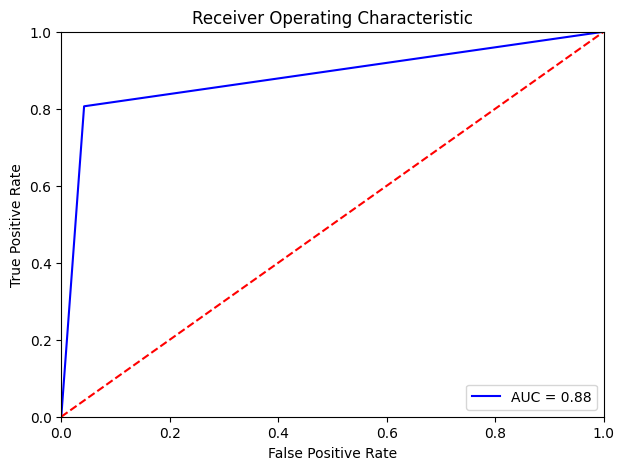

In [ ]:
#Plot  AUC-ROC CURVE
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

plt.figure(figsize=(7, 5))

fpr, tpr, threshold = metrics.roc_curve(y_true,y_pred)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic (ROC Score)')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# R^2 & F1 Score
from sklearn.metrics import r2_score,f1_score
print ("R^2 Value", r2_score(y_true, y_pred))
print ("F1 Score", f1_score(y_true, y_pred))

R^2 Value 0.5211520309766562
F1 Score 0.8733620756567574


In [ ]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_true, y_pred)
print(f"MCC Score: {mcc:.4f}")

MCC Score: 0.7710
